In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../../../../Data/Iris.csv")
df.drop(columns=['Id'], inplace=True)
df = df[df['Species'] != 'Iris-setosa']
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
50,7.0,3.2,4.7,1.4,Iris-versicolor
51,6.4,3.2,4.5,1.5,Iris-versicolor
52,6.9,3.1,4.9,1.5,Iris-versicolor
53,5.5,2.3,4.0,1.3,Iris-versicolor
54,6.5,2.8,4.6,1.5,Iris-versicolor
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def modelAccuracy(model):
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    return {
        "Accuracy:": accuracy_score(y_test, y_pred),
        "Precision:": precision_score(y_test, y_pred),
        "Recall:": recall_score(y_test, y_pred),
    }
        
        

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score

def binaryMetrices(classifier):
    classifier.fit(X_train,y_train)
    y_pred = classifier.predict(X_test)
    print("Accuracy: ",accuracy_score(y_test, y_pred))
    print("Precision: ",precision_score(y_test, y_pred))
    print("Recall: ",recall_score(y_test, y_pred))
    print("F1 score: ",f1_score(y_test, y_pred))
    print("Confusion Matrix: ")
    
    plt.figure(figsize=(6,4))
    labels = np.unique(y_test)
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
    

# 1. Classification with different algo

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

estimator_list = [
    ("lr",LogisticRegression()),
    ("knn",KNeighborsClassifier()),
    ("rf", RandomForestClassifier())
]

### validate every model

In [8]:
from sklearn.model_selection import cross_val_score

for model in estimator_list:
    score = np.mean(cross_val_score(model[1], X,y, scoring='accuracy', cv=10))
    print(model[0]," : ",round(score,3))

lr  :  0.96
knn  :  0.95
rf  :  0.95


# 1.1 Hard Voting

In [9]:
from sklearn.ensemble import VotingClassifier

hard_vote_clf = VotingClassifier(estimators=estimator_list,voting='hard')
print("Cross Val Score: ",np.mean(cross_val_score(hard_vote_clf, X,y, cv=10, scoring='accuracy')))
print(modelAccuracy(hard_vote_clf))

Cross Val Score:  0.96
{'Accuracy:': 0.95, 'Precision:': 0.8888888888888888, 'Recall:': 1.0}


Accuracy:  0.95
Precision:  0.8888888888888888
Recall:  1.0
F1 score:  0.9411764705882353
Confusion Matrix: 


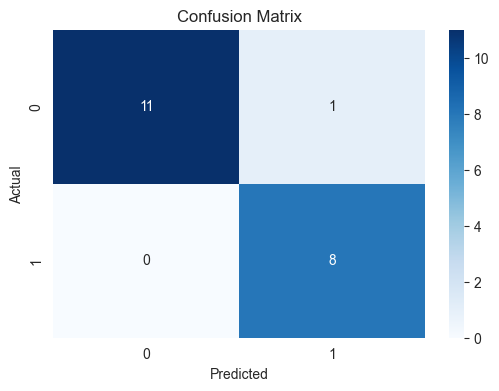

In [10]:
binaryMetrices(hard_vote_clf)

# 1.2 Soft Voting

In [11]:
soft_vote_clf = VotingClassifier(estimators=estimator_list,voting='soft')
print("Cross Val Score: ",np.mean(cross_val_score(soft_vote_clf, X,y, cv=10, scoring='accuracy')))
print(modelAccuracy(soft_vote_clf))

Cross Val Score:  0.9400000000000001
{'Accuracy:': 0.95, 'Precision:': 0.8888888888888888, 'Recall:': 1.0}


Accuracy:  0.95
Precision:  0.8888888888888888
Recall:  1.0
F1 score:  0.9411764705882353
Confusion Matrix: 


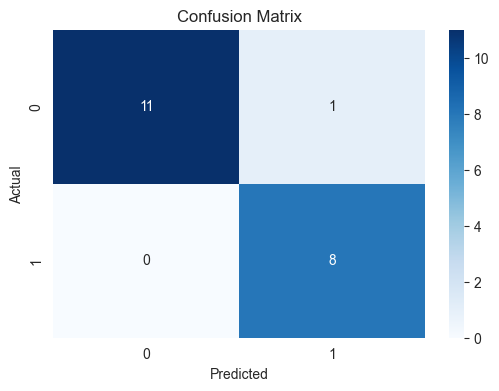

In [12]:
binaryMetrices(soft_vote_clf)

# 1.3 Weighted Voting

In [13]:
def weightedVoting(max_weight):
    maxAcc, ithm, jthm, kthm = 0, 0, 0, 0
    for i in range(1, max_weight+1):
        for j in range(1, max_weight+1):
            for k in range(1, max_weight+1):
                weightedVote_clf = VotingClassifier(estimators=estimator_list, voting='soft', weights=[i,j,k])
                score = np.mean(cross_val_score(weightedVote_clf, X, y, scoring='accuracy', cv=5))
                if score > maxAcc:
                    maxAcc = score
                    ithm = i 
                    jthm = j
                    kthm = k
    return maxAcc, ithm, jthm, kthm

In [14]:
weightedVoting(4)

(np.float64(0.96), 1, 4, 1)

In [15]:
weighted_vote_clf = VotingClassifier(estimators=estimator_list,voting='soft', weights=[1,4,1])
print("Cross Val Score: ",np.mean(cross_val_score(weighted_vote_clf, X,y, cv=10, scoring='accuracy')))
print(modelAccuracy(weighted_vote_clf))

Cross Val Score:  0.95
{'Accuracy:': 0.95, 'Precision:': 0.8888888888888888, 'Recall:': 1.0}


Accuracy:  0.95
Precision:  0.8888888888888888
Recall:  1.0
F1 score:  0.9411764705882353
Confusion Matrix: 


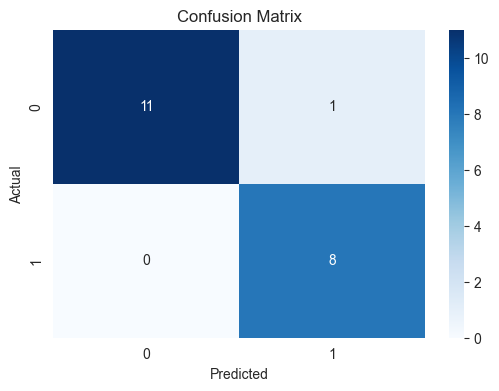

In [16]:
binaryMetrices(weighted_vote_clf)

# 2. Classification with same alog

In [17]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    random_state=2
)

In [18]:
from sklearn.svm import SVC

same_estimator_list = [
    ("svc1",SVC(probability=True,kernel='poly',degree=1)),
    ("svc2",SVC(probability=True,kernel='poly',degree=2)),
    ("svc3",SVC(probability=True,kernel='poly',degree=3)),
    ("svc4",SVC(probability=True,kernel='poly',degree=4)),
    ("svc5",SVC(probability=True,kernel='poly',degree=5))
]

In [19]:
for model in same_estimator_list:
    score = np.mean(cross_val_score(model[1], X,y, scoring='accuracy', cv=10))
    print(model[0]," : ",round(score,3))

svc1  :  0.854
svc2  :  0.853
svc3  :  0.894
svc4  :  0.809
svc5  :  0.864


In [20]:
sameAlgo_vote_clf = VotingClassifier(estimators=same_estimator_list,voting='soft')
print("Cross Val Score: ",np.mean(cross_val_score(sameAlgo_vote_clf, X,y, cv=10, scoring='accuracy')))
print(modelAccuracy(sameAlgo_vote_clf))

Cross Val Score:  0.9260000000000002
{'Accuracy:': 0.9, 'Precision:': 0.8, 'Recall:': 1.0}


Accuracy:  0.9
Precision:  0.8
Recall:  1.0
F1 score:  0.8888888888888888
Confusion Matrix: 


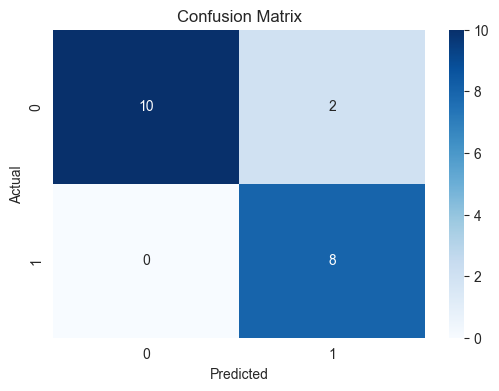

In [21]:
binaryMetrices(sameAlgo_vote_clf)